<a href="https://colab.research.google.com/github/elsolimecanico/Reconstrucci-n-de-Campos-de-Flujo-con-Super-Resoluci-n-mediante-CNNs-con-F-sica-Incorporada/blob/main/fase2_entrenamiento_cnn_superresolucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 2 — Entrenamiento de la CNN de Super-Resolución (Cylinder Wake)

**Objetivo:** entrenar una red que reciba el campo de velocidad en baja resolución (`low_res_ux`, `low_res_uy` de la Fase 1) y reconstruya el campo en alta resolución.

**Enfoque elegido: pre-upsampling + refinamiento residual (estilo SRCNN).**
En vez de una arquitectura que aprende a subir resolución dentro de la red (post-upsampling con `PixelShuffle`), primero hacemos un upsampling clásico (interpolación bicúbica) al tamaño objetivo, y luego una CNN aprende a **corregir los detalles** que la interpolación no capturó (los vórtices finos). Es más simple de implementar sin errores de shapes, y es exactamente el enfoque del paper original de Fukami et al. (2019) para este mismo caso de prueba.

**Requisito:** haber corrido la Fase 1 y tener guardados `high_res_ux.npy`, `high_res_uy.npy`, `low_res_ux.npy`, `low_res_uy.npy` (idealmente en tu Google Drive, para que persistan entre sesiones).

## 1. Cargar el dataset

Si guardaste el dataset en Drive en la Fase 1, monta Drive aquí también. Si lo tienes en el entorno temporal de Colab de la misma sesión, no hace falta.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os

DATASET_DIR = '/content/drive/MyDrive/proyecto_fluidos'  # cámbialo a la ruta en Drive si aplica, ej: '/content/drive/MyDrive/dataset_cylinder_wake'

high_res_ux = np.load(os.path.join(DATASET_DIR, 'high_res_ux.npy'))
high_res_uy = np.load(os.path.join(DATASET_DIR, 'high_res_uy.npy'))
low_res_ux  = np.load(os.path.join(DATASET_DIR, 'low_res_ux.npy'))
low_res_uy  = np.load(os.path.join(DATASET_DIR, 'low_res_uy.npy'))

print('high_res_ux:', high_res_ux.shape)
print('high_res_uy:', high_res_uy.shape)
print('low_res_ux: ', low_res_ux.shape)
print('low_res_uy: ', low_res_uy.shape)

assert high_res_ux.shape == high_res_uy.shape, 'ux/uy de alta resolución no calzan -- revisa el fix de at_centers() en la Fase 1'
assert low_res_ux.shape == low_res_uy.shape, 'ux/uy de baja resolución no calzan -- revisa el fix de at_centers() en la Fase 1'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

high_res_ux: (200, 64, 128)
high_res_uy: (200, 64, 128)
low_res_ux:  (200, 16, 32)
low_res_uy:  (200, 16, 32)
Device: cuda


In [ ]:
import os

# Listar los archivos en el DATASET_DIR
print(f"Archivos en '{DATASET_DIR}':")
for item in os.listdir(DATASET_DIR):
    print(item)

Archivos en '/content/drive/MyDrive/proyecto_fluidos':
high_res_ux.npy
high_res_uy.npy
low_res_ux.npy
low_res_uy.npy
modelos


## 2. Apilar canales y normalizar

Juntamos `ux` y `uy` como 2 canales de una misma "imagen" (formato `NCHW`, el estándar de PyTorch para CNNs).

**Sobre la normalización:** las estadísticas (media/desviación estándar) se calculan **solo con el set de entrenamiento**, nunca con todo el dataset. Si normalizas con estadísticas de todo el dataset (incluyendo val/test), estás filtrando información del futuro hacia el entrenamiento -- un error común pero serio en series de tiempo.

In [ ]:
# Apilar canales: (N, 2, H, W)
high_res = np.stack([high_res_ux, high_res_uy], axis=1).astype(np.float32)
low_res  = np.stack([low_res_ux,  low_res_uy],  axis=1).astype(np.float32)

N = high_res.shape[0]
print('Total de snapshots:', N)

# --- División temporal (NO aleatoria) ---
# 70% train / 15% val / 15% test, en bloques contiguos de tiempo
n_train = int(0.70 * N)
n_val   = int(0.15 * N)

train_idx = slice(0, n_train)
val_idx   = slice(n_train, n_train + n_val)
test_idx  = slice(n_train + n_val, N)

print(f'Train: {n_train} frames | Val: {n_val} frames | Test: {N - n_train - n_val} frames')

# --- Normalización (estadísticas SOLO del train) ---
mean_hr = high_res[train_idx].mean(axis=(0, 2, 3), keepdims=True)
std_hr  = high_res[train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-8
mean_lr = low_res[train_idx].mean(axis=(0, 2, 3), keepdims=True)
std_lr  = low_res[train_idx].std(axis=(0, 2, 3), keepdims=True) + 1e-8

high_res_norm = (high_res - mean_hr) / std_hr
low_res_norm  = (low_res  - mean_lr) / std_lr

print('Media/std (train) -- alta res:', mean_hr.flatten(), std_hr.flatten())
print('Media/std (train) -- baja res:', mean_lr.flatten(), std_lr.flatten())

Total de snapshots: 200
Train: 140 frames | Val: 30 frames | Test: 30 frames
Media/std (train) -- alta res: [ 8.4585720e-01 -2.0489097e-09] [0.24651307 0.09009033]
Media/std (train) -- baja res: [0.84267527 0.00247684] [0.24923779 0.09022652]


## 3. Dataset y DataLoader

El upsampling bicúbico (a la resolución alta objetivo) lo hacemos **dentro del `Dataset`**, así el modelo siempre recibe una entrada ya en el tamaño final -- esto es justamente el enfoque "pre-upsampling" que mencionamos arriba.

In [ ]:
class CylinderWakeDataset(Dataset):
    def __init__(self, low_res, high_res, index_slice):
        self.low_res = torch.from_numpy(low_res[index_slice]).float()
        self.high_res = torch.from_numpy(high_res[index_slice]).float()
        self.target_hw = self.high_res.shape[-2:]

    def __len__(self):
        return self.low_res.shape[0]

    def __getitem__(self, idx):
        lr = self.low_res[idx].unsqueeze(0)  # (1, 2, h, w)
        lr_upsampled = F.interpolate(lr, size=self.target_hw, mode='bicubic', align_corners=False).squeeze(0)
        hr = self.high_res[idx]
        return lr_upsampled, hr

train_ds = CylinderWakeDataset(low_res_norm, high_res_norm, train_idx)
val_ds   = CylinderWakeDataset(low_res_norm, high_res_norm, val_idx)
test_ds  = CylinderWakeDataset(low_res_norm, high_res_norm, test_idx)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)   # shuffle OK aquí: ya separamos por tiempo antes
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# Verificación rápida de shapes
lr_batch, hr_batch = next(iter(train_loader))
print('Batch low-res (upsampleado):', lr_batch.shape)
print('Batch high-res (target):   ', hr_batch.shape)

Batch low-res (upsampleado): torch.Size([16, 2, 64, 128])
Batch high-res (target):    torch.Size([16, 2, 64, 128])


## 4. Arquitectura de la CNN

Nada exótico a propósito: 5 capas convolucionales con `ReLU`, y una **conexión residual** (la red aprende a predecir la *corrección* sobre la interpolación bicúbica, no el campo completo desde cero -- esto suele entrenar más rápido y estable que predecir el campo absoluto).

In [ ]:
class SRCNNResidual(nn.Module):
    def __init__(self, in_channels=2, hidden_channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=9, padding=4),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, in_channels, kernel_size=5, padding=2),  # sin activación al final
        )

    def forward(self, x_upsampled):
        correction = self.net(x_upsampled)
        return x_upsampled + correction  # conexión residual

model = SRCNNResidual(in_channels=2, hidden_channels=32).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parámetros del modelo: {n_params:,}')

Parámetros del modelo: 67,330


## 5. Loop de entrenamiento

Loss: MSE simple entre el campo reconstruido y el ground truth (ambos normalizados). Guardamos también el error de validación en cada época para vigilar overfitting.

In [ ]:
N_EPOCHS = 60
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    model.train()
    running_loss = 0.0
    for lr_batch, hr_batch in train_loader:
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        optimizer.zero_grad()
        pred = model(lr_batch)
        loss = criterion(pred, hr_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * lr_batch.size(0)
    train_loss = running_loss / len(train_ds)

    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for lr_batch, hr_batch in val_loader:
            lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
            pred = model(lr_batch)
            running_val += criterion(pred, hr_batch).item() * lr_batch.size(0)
    val_loss = running_val / len(val_ds)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 5 == 0 or epoch == N_EPOCHS - 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}')

Epoch   0/60 | train_loss=0.04539 | val_loss=0.01755
Epoch   5/60 | train_loss=0.00425 | val_loss=0.00362
Epoch  10/60 | train_loss=0.00241 | val_loss=0.00228
Epoch  15/60 | train_loss=0.00169 | val_loss=0.00167
Epoch  20/60 | train_loss=0.00112 | val_loss=0.00117
Epoch  25/60 | train_loss=0.00081 | val_loss=0.00092
Epoch  30/60 | train_loss=0.00060 | val_loss=0.00075
Epoch  35/60 | train_loss=0.00047 | val_loss=0.00070
Epoch  40/60 | train_loss=0.00045 | val_loss=0.00061
Epoch  45/60 | train_loss=0.00033 | val_loss=0.00047
Epoch  50/60 | train_loss=0.00029 | val_loss=0.00042
Epoch  55/60 | train_loss=0.00028 | val_loss=0.00042
Epoch  59/60 | train_loss=0.00022 | val_loss=0.00036


## 6. Curvas de pérdida

Si `val_loss` empieza a subir mientras `train_loss` sigue bajando, es overfitting -- con un dataset chico (unos cientos de snapshots) es bastante probable que lo veas. No es motivo de alarma para un proyecto de portafolio, pero documéntalo: es exactamente el tipo de observación que hace ver tu análisis como riguroso.

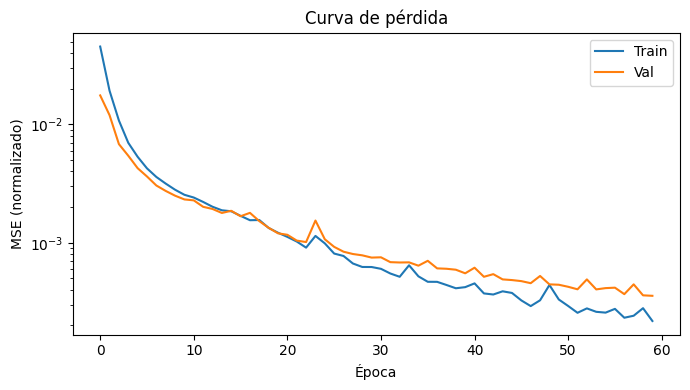

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Época')
plt.ylabel('MSE (normalizado)')
plt.yscale('log')
plt.legend()
plt.title('Curva de pérdida')
plt.tight_layout()
plt.show()

## 7. Evaluación cuantitativa en el set de test

Métrica: **error L2 relativo**, la más usada en la literatura de super-resolución de flujos (Fukami et al. la reportan así), definida como:

$$ \text{Error L2 relativo} = \frac{\lVert u_{pred} - u_{true} \rVert_2}{\lVert u_{true} \rVert_2} $$

Comparamos también contra el **baseline ingenuo**: solo la interpolación bicúbica, sin pasar por la CNN. Esto es clave -- si tu CNN no le gana claramente a la interpolación simple, no tienes un resultado defendible.

In [ ]:
def relative_l2_error(pred, true):
    return (torch.norm(pred - true) / torch.norm(true)).item()

model.eval()
cnn_errors, baseline_errors = [], []

with torch.no_grad():
    for lr_batch, hr_batch in test_loader:
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        pred = model(lr_batch)
        cnn_errors.append(relative_l2_error(pred, hr_batch))
        baseline_errors.append(relative_l2_error(lr_batch, hr_batch))  # lr_batch ya viene bicubic-upsampleado

print(f'Error L2 relativo -- CNN:               {np.mean(cnn_errors):.4f}')
print(f'Error L2 relativo -- Solo bicúbico:     {np.mean(baseline_errors):.4f}')
print(f'Mejora relativa de la CNN sobre el baseline: {(1 - np.mean(cnn_errors)/np.mean(baseline_errors))*100:.1f}%')

Error L2 relativo -- CNN:               0.0217
Error L2 relativo -- Solo bicúbico:     0.2202
Mejora relativa de la CNN sobre el baseline: 90.1%


## 8. Comparación visual (el resultado que va en el README/portafolio)

Comparamos, para un frame de test: **entrada bicúbica** (baseline) vs. **reconstrucción CNN** vs. **ground truth**, tanto en velocidad como en vorticidad. La vorticidad es más exigente visualmente porque amplifica errores de pequeña escala -- si tu CNN se ve bien ahí, el resultado es sólido.

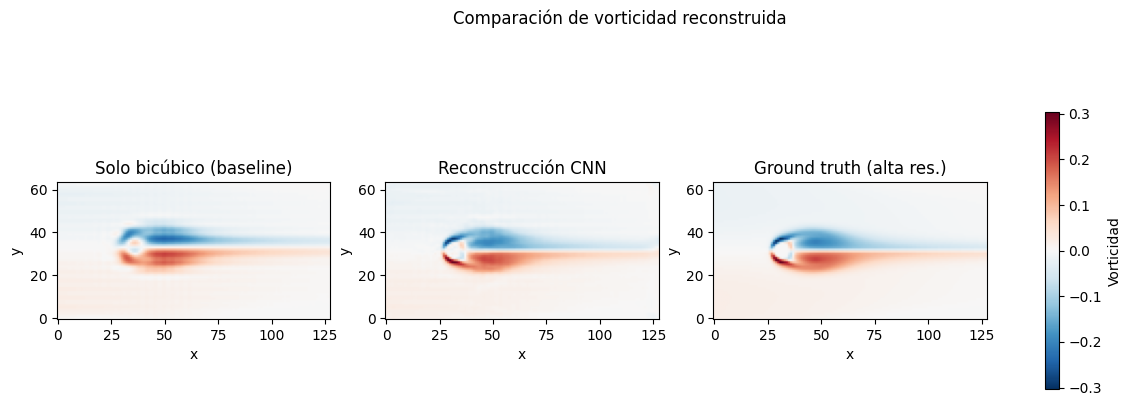

In [ ]:
def compute_vorticity(ux, uy):
    return np.gradient(uy, axis=1) - np.gradient(ux, axis=0)

# Tomamos un solo frame de test para visualizar
sample_idx = 0
lr_sample, hr_sample = test_ds[sample_idx]

with torch.no_grad():
    pred_sample = model(lr_sample.unsqueeze(0).to(device)).cpu().squeeze(0)

# Desnormalizar para que las magnitudes tengan sentido físico
def denormalize(x, mean, std):
    # NOTA: mean/std vienen con shape (2,1,1) -- NO usar .squeeze() aquí,
    # porque colapsaría a (2,) y rompe el broadcasting contra un campo (2,H,W)
    # (numpy alinea shapes desde la derecha: (2,H,W) vs (2,) compara W con 2, no canal con canal).
    return x.numpy() * std + mean

hr_denorm      = denormalize(hr_sample,   mean_hr[0], std_hr[0])
pred_denorm    = denormalize(pred_sample, mean_hr[0], std_hr[0])
bicubic_denorm = denormalize(lr_sample,   mean_hr[0], std_hr[0])  # lr_sample ya está en la escala 'alta' por el upsample

vort_true    = compute_vorticity(hr_denorm[0],      hr_denorm[1])
vort_pred    = compute_vorticity(pred_denorm[0],    pred_denorm[1])
vort_bicubic = compute_vorticity(bicubic_denorm[0], bicubic_denorm[1])

vmax = np.abs(vort_true).max()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
titles = ['Solo bicúbico (baseline)', 'Reconstrucción CNN', 'Ground truth (alta res.)']
fields = [vort_bicubic, vort_pred, vort_true]
for ax, field, title in zip(axes, fields, titles):
    im = ax.imshow(field, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')
fig.colorbar(im, ax=axes, shrink=0.8, label='Vorticidad')
plt.suptitle('Comparación de vorticidad reconstruida', y=1.03)
plt.show()

## 9. Guardar el modelo entrenado

In [ ]:
from google.colab import drive
import os

# 1. Conectar Drive (si ya está montado, no hace nada, solo confirma)
drive.mount('/content/drive')

# 2. Carpeta permanente dentro de tu Drive -- misma carpeta de proyecto que usaste en la Fase 1
MODEL_DIR = '/content/drive/MyDrive/proyecto_fluidos/modelos'
os.makedirs(MODEL_DIR, exist_ok=True)

# 3. Guardar el checkpoint ahí
torch.save({
    'model_state_dict': model.state_dict(),
    'mean_hr': mean_hr, 'std_hr': std_hr,
    'mean_lr': mean_lr, 'std_lr': std_lr,
    'n_epochs': N_EPOCHS,
    'final_train_loss': train_losses[-1],
    'final_val_loss': val_losses[-1],
}, os.path.join(MODEL_DIR, 'srcnn_cylinder_wake.pt'))

print(f'¡Modelo guardado permanentemente en tu Drive en: {MODEL_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡Modelo guardado permanentemente en tu Drive en: /content/drive/MyDrive/proyecto_fluidos/modelos


## 10. Próximos pasos (Fase 3, opcional pero recomendada)

Con esto ya tienes un resultado completo y defendible: dataset propio + modelo entrenado + métricas + comparación visual. Para llevarlo un nivel más allá:

1. **Término de pérdida físico (estilo PINN ligero):** añadir a la loss una penalización por divergencia del campo reconstruido (`div(u) ≈ 0` para flujo incompresible). No hace falta resolver Navier-Stokes dentro de la red -- basta con calcular la divergencia por diferencias finitas sobre la salida y sumarla como término extra a la MSE.
2. **Comparar contra una GAN simple:** mismo dataset, pero con un discriminador -- vas a ver que la GAN produce texturas de pequeña escala más realistas, aunque con menos garantías físicas (es justo la discusión que documentan Fukami et al. entre sus variantes CNN vs. GAN).
3. **Generalización:** entrenar con un Reynolds y evaluar en otro (ej. entrenar a Re=100, testear a Re=150) -- esto es lo que separa un proyecto de tutorial de un proyecto de investigación real, porque expone si el modelo aprendió física o solo memorizó el patrón.
4. **Documentar en GitHub:** README con motivación, arquitectura, las imágenes de este notebook, la tabla de error L2 relativo (CNN vs. bicúbico), y citar explícitamente a Fukami, Fukagata & Taira (2019) como marco de referencia.

**Checklist de esta fase:**
- [ ] El error L2 relativo de la CNN es menor que el del baseline bicúbico (si no, revisa `N_EPOCHS`, `LR`, o el tamaño del dataset).
- [ ] La curva de val_loss no diverge de forma descontrolada respecto a train_loss.
- [ ] La comparación visual de vorticidad muestra que la CNN recupera estructuras que el bicúbico no captura.